<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exploratory Data Analysis for Modeling

---

### About
In this notebook, we'll explore the critical steps of performing Exploratory Data Analysis (EDA) with machine learning modeling in mind. EDA is not just about understanding your data – it's about making informed decisions that will affect your entire modeling pipeline.

### Learning Objectives
We'll use several real-world data sets to explore:
- Why data exploration is crucial for successful modeling.
- Random variables and their distributions.
- How distributions inform our modeling approach.
- Correlation and its role in feature selection.
- The critical distinction between correlation and causation.

### Notebook Guide
1. Setup and Data Loading
2. Why Explore Data for Modeling?
3. Distributions and Modeling Approach
4. Correlation Analysis
5. Conclusions and Key Takeaways
6. Practice Exercises

# 1. Setup and Data Loading

First, let's import the necessary libraries and load our data sets. We'll work with multiple data sets to illustrate different concepts.

In [3]:
# Import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression 

from sklearn.metrics import r2_score, root_mean_squared_error 

# Set the plotting style
sns.set_theme(style="darkgrid", palette="husl")
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

Let's load several data sets for our exploration:

In [4]:
# Load the California Housing data set - a shortened version of the data used in the first part of Aurelion Geron's
# book Hands-On Machine Learning with Scikit-Learn & TensorFlow
housing_df = pd.read_csv('../03-data/housing-geron.csv')

# Load the Iris data set
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

# Inspect the shapes of each DataFrame
print("Data sets loaded successfully!")
print(f"California Housing: {housing_df.shape}")
print(f"Iris: {iris_df.shape}")

Data sets loaded successfully!
California Housing: (20640, 10)
Iris: (150, 5)


# 2. Why Explore Data for Modeling?

Before we build any machine learning model, we need to understand our data. Let's explore why this is crucial.

### Exercise 1: Initial Data Exploration

Complete the code below to perform initial exploration of the California Housing data set. This will help us understand what we're working with.

In [5]:
# Ex1: Display basic information about the California Housing data set

# Display the first few rows of the data set
print("First 5 rows of the data set:")
housing_df.head(10)

First 5 rows of the data set:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


| Feature | Description |
|---|---|
| `longitude` | Longitude coordinate of the geographic area/block group. |
| `latitude` | Latitude coordinate of the geographic area/block group. |
| `housing_median_age` | Median age of houses in the area, in years. |
| `total_rooms` | Total number of rooms across all households in the area. |
| `total_bedrooms` | Total number of bedrooms across all households in the area. |
| `population` | Total number of people living in the area. |
| `households` | Total number of households in the area. |
| `median_income` | Median household income in the area, expressed in units of \$10,000. For example, `8.3` ≈ \$83,000. |
| `median_house_value` | Median house value in the area, in US dollars. Usually used as the target variable. |
| `ocean_proximity` | Categorical variable describing how close the area is to the ocean, e.g. `NEAR BAY`, `INLAND`, `NEAR OCEAN`. |

> **Each row represents a geographic block group / area, not an individual house.**

In [6]:
# Display the data types and missing values information
print("\nData set info:")
housing_df.info()


Data set info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [7]:
# Display summary statistics
print("\nSummary statistics:")
housing_df.describe()


Summary statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### What can we learn from describe()?
- Typical values → mean and 50% (median) tell us where most observations are centered.
- Possible skewness → a large difference between the mean and median can suggest a skewed distribution.
- Potential outliers → compare min/max with the 25th and 75th percentiles.
- Spread / variability → std and the quartiles tell us how much each feature varies.
- Different feature scales → some variables may be in very different numerical ranges, which matters for models that require scaling.
- Suspicious limits or impossible values → unusually exact maximum/minimum values may indicate data caps or data-quality issues.

In [8]:
# Display summary statistics for categorical data
print("\nCategorical summary statistics:")
housing_df.describe(include="object")


Categorical summary statistics:


C:\Users\TALAL ALOTHMAN\AppData\Local\Temp\ipykernel_23848\1310164054.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  housing_df.describe(include="object")


,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


### Exercise 2: Data Quality Issues

Let's create a function to identify potential data quality issues that could affect our modeling.

In [9]:
# Check for missing values
housing_df.isnull().mean().sort_values(ascending=False)*100

total_bedrooms        1.002907
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

#### How to deal with missing values?

* **Investigate why values are missing first** — missingness may be random or systematic.
* **Try to recover the missing values from another trusted source** if possible, such as another database, API, or original record.
* **Drop rows** when the percentage of missing values is very small, e.g. around **< 1–2%** ,and removing them will not bias the dataset.

> _Dropping rows is safer when the missing rows look similar to the rest of the data and are not concentrated in a particular group._

* **Drop a feature/column** when a very large proportion is missing, e.g. **> 30%**, especially if the feature is not essential. 

> _These percentages are guidelines, not strict rules._

* **Impute numerical features** using:

  * **Mean** when the distribution is fairly symmetric and has few extreme values.
  * **Median** when the data is skewed or contains outliers.
* **Impute categorical features** using the most frequent category or create a separate `"Missing"` / `"Unknown"` category when missingness itself may be informative.
* **Use model-based imputation** for more complex cases, e.g. KNN imputation
* **Use domain knowledge to fill values only when there is a clear, defensible rule** — avoid simply inventing values.


In [10]:
# Check for duplicate rows
housing_df.duplicated().sum()

np.int64(0)

In [11]:
# Identify potential outliers for numerical columns
outliers = {}

for col in housing_df.select_dtypes(include=[np.number]).columns:
    q1 = housing_df[col].quantile(0.25)
    q3 = housing_df[col].quantile(0.75)
    
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
        
    outliers[col] = ( (housing_df[col] < lower) | (housing_df[col] > upper)).sum()
        
outliers

{'longitude': np.int64(0),
 'latitude': np.int64(0),
 'housing_median_age': np.int64(0),
 'total_rooms': np.int64(1287),
 'total_bedrooms': np.int64(1271),
 'population': np.int64(1196),
 'households': np.int64(1220),
 'median_income': np.int64(681),
 'median_house_value': np.int64(1071)}

#### How to deal with outliers? 

- **Investigate first** — determine whether the outlier is a real value or a data error.
- **Correct or remove it** — only if it is clearly incorrect or impossible.
- **Keep i**t — if it is a valid extreme observation and relevant to the real population.
- **Choose robust evaluation metrics** — for regression, MAE is less sensitive to extreme target errors than MSE/RMSE.
- **Build a separate model/segment only if justified** — e.g. luxury houses may genuinely behave differently from ordinary houses.
- **Use models that are not sensitive to outliers**

Later in feature engineering module we will learn:
- **Transform the variable** — e.g. log1p() for strongly right-skewed positive features or targets.
- **Cap / winsorize** — replace extreme values with a reasonable upper/lower boundary instead of deleting the row.
- **Use robust preprocessing/models** — e.g. RobustScaler or models less sensitive to extreme values.

In [26]:
# TO DO:

# Two in One: Check for inconsistent categories & distribution
for col in housing_df.select_dtypes(include=["object"]).columns:
    print(f"{col}: values distribution\n")
    print(housing_df[col].value_counts(normalize=True)*100)

ocean_proximity: values distribution

ocean_proximity
<1H OCEAN     44.263566
INLAND        31.739341
NEAR OCEAN    12.877907
NEAR BAY      11.094961
ISLAND         0.024225
Name: proportion, dtype: float64


C:\Users\TALAL ALOTHMAN\AppData\Local\Temp\ipykernel_23848\2380223595.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in housing_df.select_dtypes(include=["object"]).columns:


In [28]:
#STRETCH: Wrapping up your data quality logic in a function

def identify_data_issues(df):
    """
    Identify potential data quality issues in a dataframe.
    
    Returns:
    - Missing values per column
    - Duplicate rows
    - Potential outliers (values beyond 3 standard deviations)
    """
    issues = {}
    
    # Check for missing values
    issues['missing_values'] = round( df.isnull().mean()*100,3)
    
    # Check for duplicate rows
    issues['duplicates'] = df.duplicated().sum()
    
    # Identify potential outliers for numerical columns
    outliers = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        outliers[col] = ((df[col] < lower) | (df[col] > upper)).sum()
        
        issues['outliers'] = outliers
    
    return issues

# Test the function on Housing data
issues = identify_data_issues(housing_df)
print("Data Quality Issues:\n")
print(f"Missing values:\n{issues['missing_values']}")
print(f"\nDuplicate rows: {issues['duplicates']}")
print(f"\nOutliers per column:\n{issues['outliers']}")

Data Quality Issues:

Missing values:
longitude             0.000
latitude              0.000
housing_median_age    0.000
total_rooms           0.000
total_bedrooms        1.003
population            0.000
households            0.000
median_income         0.000
median_house_value    0.000
ocean_proximity       0.000
dtype: float64

Duplicate rows: 0

Outliers per column:
{'longitude': np.int64(0), 'latitude': np.int64(0), 'housing_median_age': np.int64(0), 'total_rooms': np.int64(1287), 'total_bedrooms': np.int64(1271), 'population': np.int64(1196), 'households': np.int64(1220), 'median_income': np.int64(681), 'median_house_value': np.int64(1071)}


### Reflection: Why EDA Matters for Modeling

Based on your initial exploration, answer these questions:

1. What potential problems did you identify that could affect model performance?
2. Why is identifying outliers important before building a model?

**Answers:**
1. The California Housing data set has several potential issues:
   - Some columns have outliers (for example `total_rooms` and `median_income`)
   - There might be collinearity between features (we'll check this later)
   - There are missing values we need to deal with
   - Feature "ocean_proximity" has a label with a very low frequency
   - Different features have very different scales, which could affect distance-based algorithms

3. Identifying outliers is important because:
   - They can disproportionately influence linear models and pull the regression line
   - They can affect the mean and standard deviation used in standardization (later in feature engineering)
   - They might represent errors, special cases, or important anomalies that need separate treatment

> _Some algorithms (like SVM) are sensitive to outliers, while others (like tree-based methods) are more robust_

---

To the slides!

---

# 3. Distributions and Modeling Approach

The distribution of variables significantly impacts our choice of modeling approach. Let's explore how.

### Exercise 5: Visualizing Distributions

Let's complete the function to create comprehensive distribution visualizations.

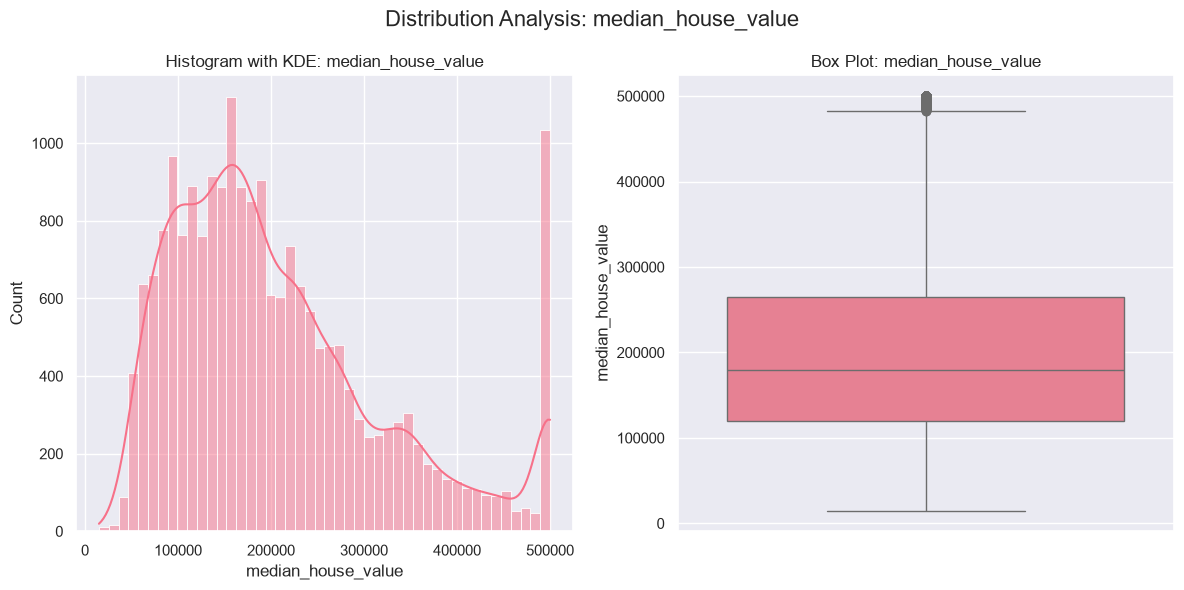

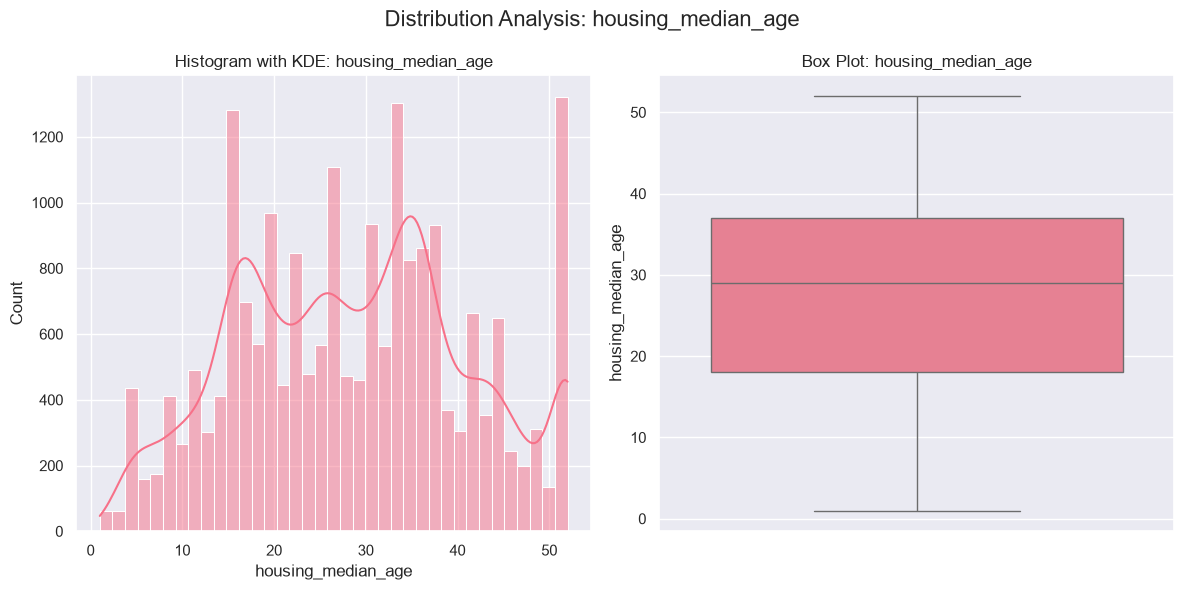

In [ ]:
def visualize_distribution(df, column):
    """
    Create comprehensive visualization of a variable's distribution.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Create histogram with KDE
    #Kernel Density Estimate (KDE) It adds a smooth curve over the histogram to show the overall shape of the data distribution.
    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram with KDE: {column}')
    
    # Create box plot
    sns.boxplot(y=df[column], ax=axes[1])
    axes[1].set_title(f'Box Plot: {column}')
    
    plt.suptitle(f'Distribution Analysis: {column}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize some variables
visualize_distribution(housing_df, 'median_house_value')
visualize_distribution(housing_df, 'housing_median_age')

#### Nice things to check from your distributions:

- Spread of data: Is it worth having the feature
- Outliers
- Range of data: Any values as error or mistake ?
- Multiple peaks: Is there a factor leading to two separate groups?

> In the next module, we will use distributions for **choosing a specific numerical transformation**


# 4. Correlation Analysis

Understanding the relationships between variables is crucial for feature selection and model interpretation.

### Exercise 6: Correlation Matrix and Heatmap

Create a comprehensive correlation analysis for the California Housing data set.

In [15]:
# Calculate correlation matrix

corr_matrix = housing_df.select_dtypes(include="number").corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


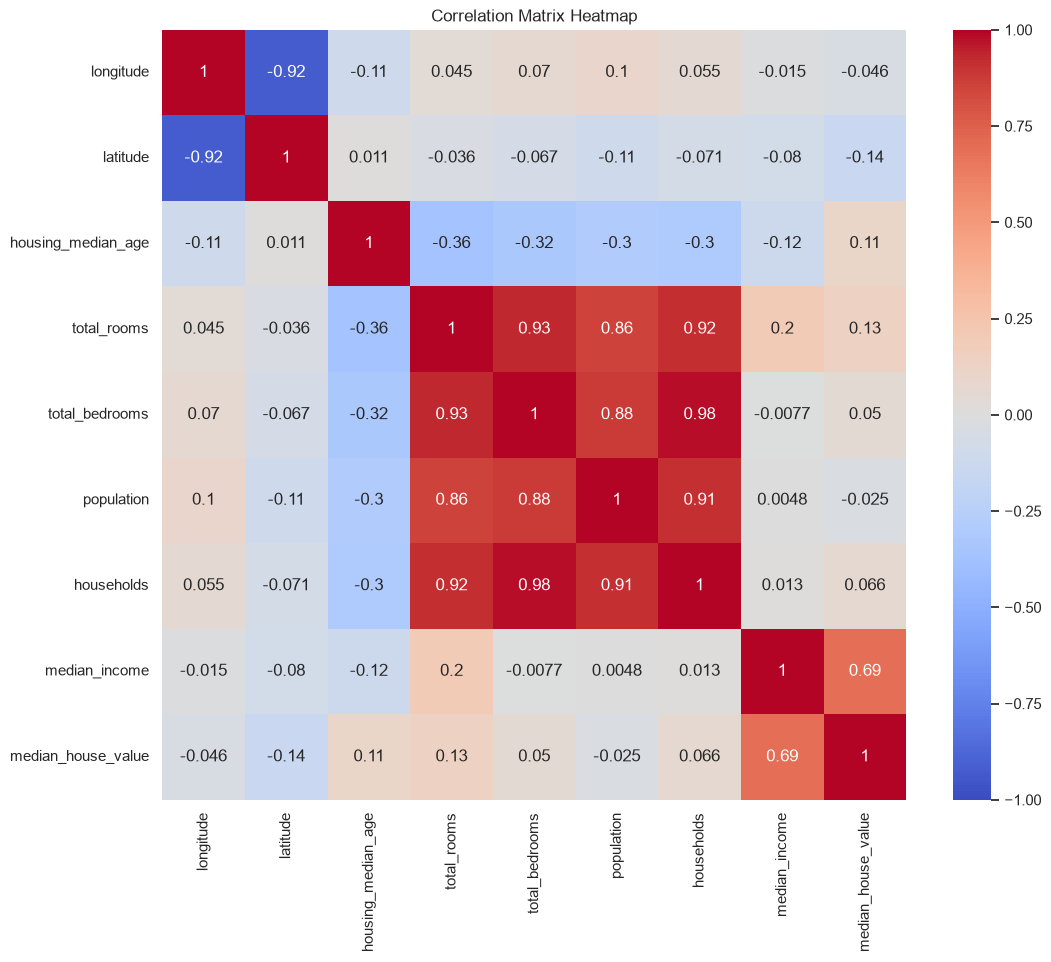

In [ ]:
# Create a heatmap

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=True # to write the actual numerical value inside each cell, 
            cmap='coolwarm',
            vmax=1,
            vmin=-1)
    
plt.title('Correlation Matrix Heatmap');


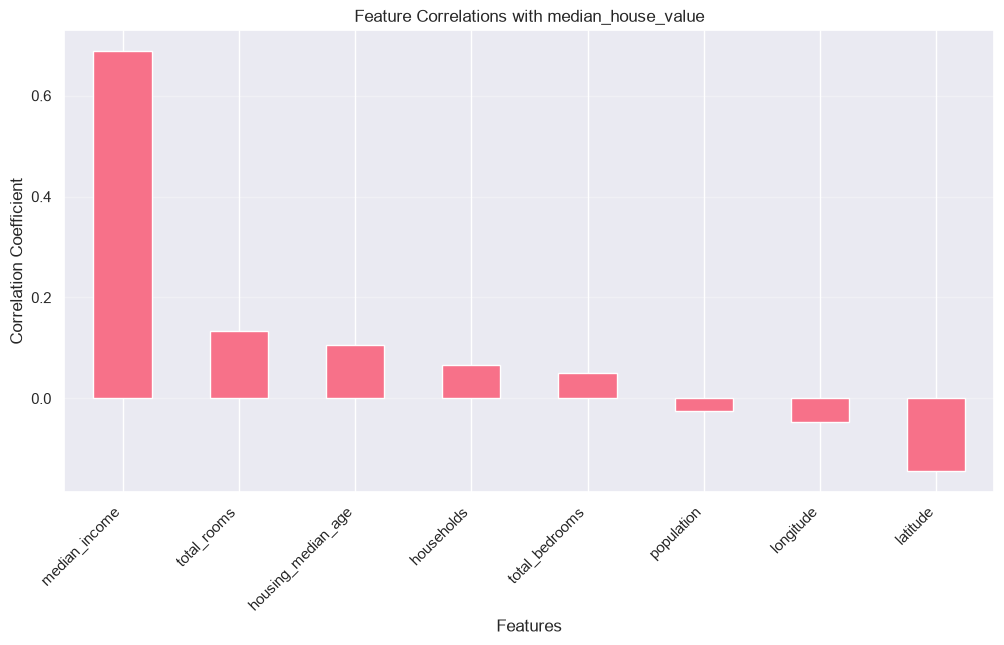

In [17]:
# Create bar plot of correlations with target

plt.figure(figsize=(12, 6))


( 
corr_matrix["median_house_value"]
    .sort_values(ascending=False)
    .drop(index='median_house_value')
    .plot(kind="bar") 
)

plt.title(f'Feature Correlations with median_house_value')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

In [18]:
# STRETCH: Identify multicollinearity (correlation > 0.8 between features)

# Convert the correlation matrix into a DataFrame
corr_df = corr_matrix.stack().reset_index()

# Rename the columns
corr_df.columns = ['feature_1','feature_2', 'correlation']

# Remove "self correlations"
corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2']]

# Remove duplicate pairs: A-B vs B-A
corr_df = corr_df[corr_df['feature_1'] < corr_df['feature_2']]

# Remove target
corr_df = corr_df[ (corr_df['feature_1'] != "median_house_value") & ( corr_df['feature_2'] != "median_house_value")]

# Compute the absolute correlation
corr_df['absolute_correlation'] = np.abs(corr_df['correlation'])

# Sort the correlation values
corr_df = corr_df.sort_values(by="absolute_correlation", ascending=False)

# Display correlations higher than or equal to 0.8
threshold = 0.8
above_threshold = corr_df["absolute_correlation"] >= 0.8
corr_df = corr_df[above_threshold]

# Final result
corr_df

,feature_1,feature_2,correlation,absolute_correlation
58,households,total_bedrooms,0.979728,0.979728
39,total_bedrooms,total_rooms,0.930380,0.930380
9,latitude,longitude,-0.924664,0.924664
57,households,total_rooms,0.918484,0.918484
59,households,population,0.907222,0.907222
49,population,total_bedrooms,0.877747,0.877747
48,population,total_rooms,0.857126,0.857126


#### How to deal with Multicollinarity

- Remove one of the highly correlated features when two variables contain very similar information.
- Choose which feature to keep based on domain relevance, fewer missing values, easier interpretation,...
- Combine correlated features when it makes sense, e.g. create a ratio or summary feature.

Later we will:
- Use regularization, especially Ridge Regression, which can reduce instability caused by correlated predictors.
- Use PCA when many features are highly correlated and dimensionality reduction is acceptable.

> _Multicollinearity is especially important for linear/logistic regression coefficient interpretation; tree-based models are generally less affected._

### Exercise 7: Different Types of Correlation

Let's compare Pearson, Spearman, Kendall and distance correlations to understand their differences.

In [19]:
# pip install dcor

In [20]:
import dcor

def compare_correlation_methods(x, y):
    """
    Compare different correlation methods.
    """
    # Calculate Pearson correlation
    pearson_corr, pearson_p = stats.pearsonr(x, y)
    
    # Calculate Spearman correlation
    spearman_corr, spearman_p = stats.spearmanr(x, y)
    
    # Calculate Kendall correlation
    kendall_corr, kendall_p = stats.kendalltau(x, y)
    
    # Distance correlation
    distance_corr = dcor.distance_correlation(x, y)
    
    # Create visualization
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    
    # Pearson
    axes[0].scatter(x, y, alpha=0.6)
    axes[0].set_title(f'Pearson r = {pearson_corr:.3f}\n(p = {pearson_p:.3f})')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    
    # Spearman
    axes[1].scatter(x, y, alpha=0.6)
    axes[1].set_title(f'Spearman ρ = {spearman_corr:.3f}\n(p = {spearman_p:.3f})')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    
    # Kendall
    axes[2].scatter(x, y, alpha=0.6)
    axes[2].set_title(f'Kendall τ = {kendall_corr:.3f}\n(p = {kendall_p:.3f})')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    
    # Distance correlation
    axes[3].scatter(x, y, alpha=0.6)
    axes[3].set_title(f'Distance Corr = {distance_corr:.3f}')
    axes[3].set_xlabel('X')
    axes[3].set_ylabel('Y')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'pearson': (pearson_corr, pearson_p),
        'spearman': (spearman_corr, spearman_p),
        'kendall': (kendall_corr, kendall_p),
        'distance': (distance_corr,0)
    }

Distance correlation ranges from 0 to 1, not -1 to 1.

- 0 → no dependence
- closer to 1 → stronger dependence

Unlike Pearson/Spearman/Kendall, distance correlation does not tell you direction.

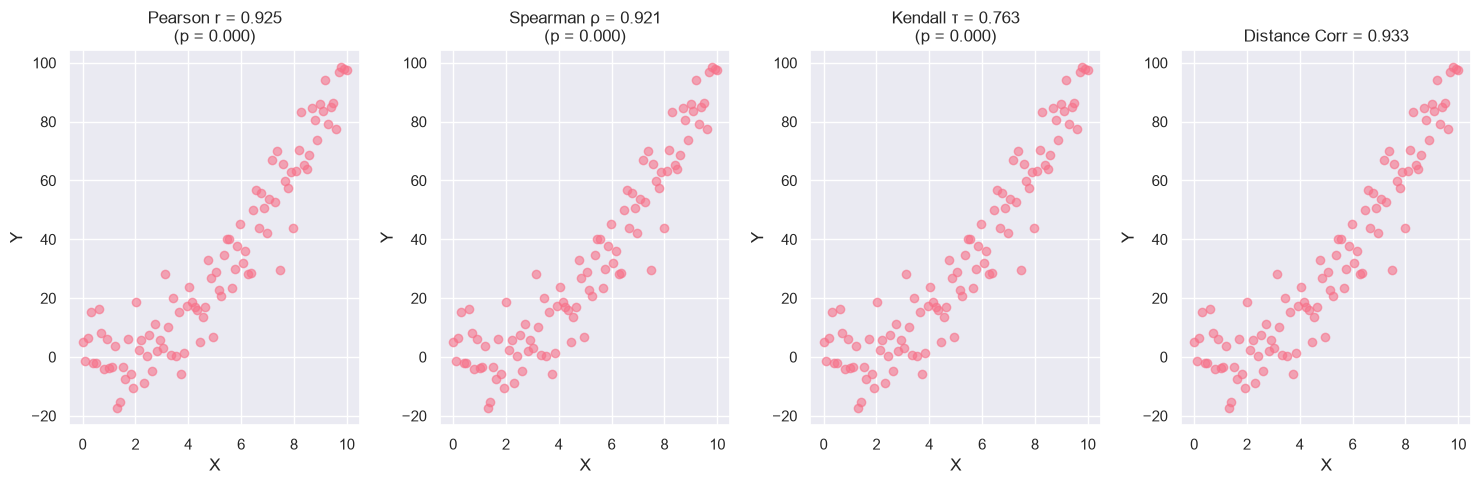

Correlation comparison for linear relationship:
pearson: 0.925 (p=0.000)
spearman: 0.921 (p=0.000)
kendall: 0.763 (p=0.000)
distance: 0.933


In [21]:
# Example 1: Create data with linear relationship
x = np.linspace(0, 10, 100)
y = x**2 + np.random.normal(0, 10, 100)

# Compare correlations
correlations = compare_correlation_methods(x, y)
print("Correlation comparison for linear relationship:")

for method, (corr, p) in correlations.items():
    if method == "distance":
        print(f"{method}: {corr:.3f}")
    else:
        print(f"{method}: {corr:.3f} (p={p:.3f})")

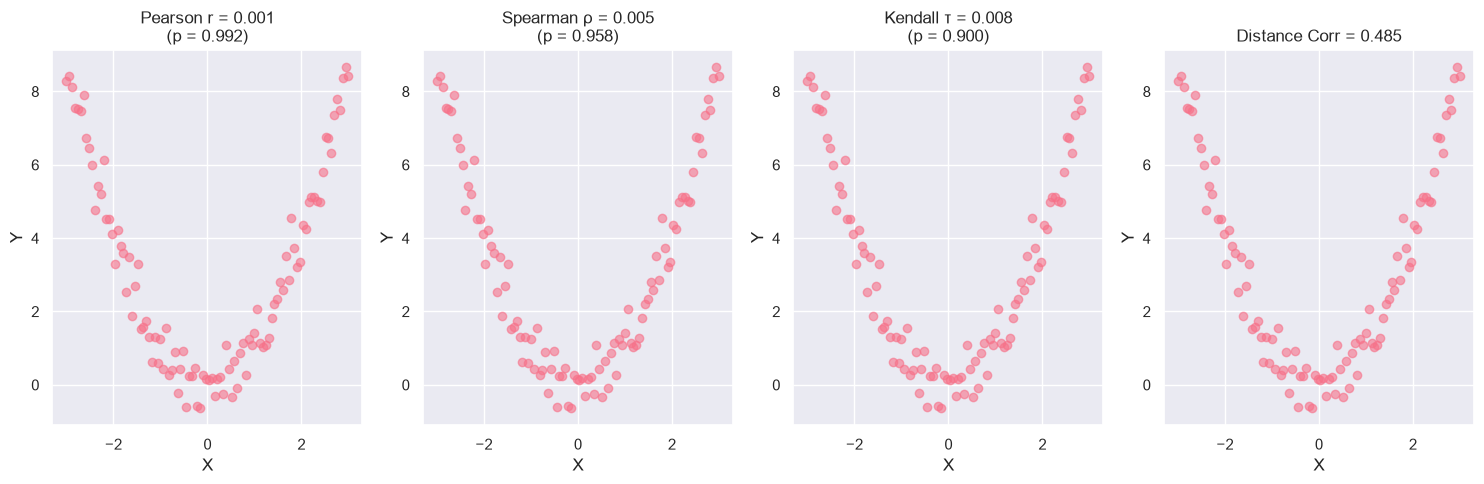

Correlation comparison for quadratic relationship:
pearson: 0.001 (p=0.992)
spearman: 0.005 (p=0.958)
kendall: 0.008 (p=0.900)
distance: 0.485


In [22]:
# Example 2: Quadratic relationship
x = np.linspace(-3, 3, 100)
y = x**2 + np.random.normal(0, 0.5, 100)

# Compare correlations
correlations = compare_correlation_methods(x, y)
print("Correlation comparison for quadratic relationship:")

for method, (corr, p) in correlations.items():
    if method == "distance":
        print(f"{method}: {corr:.3f}")
    else:
        print(f"{method}: {corr:.3f} (p={p:.3f})")

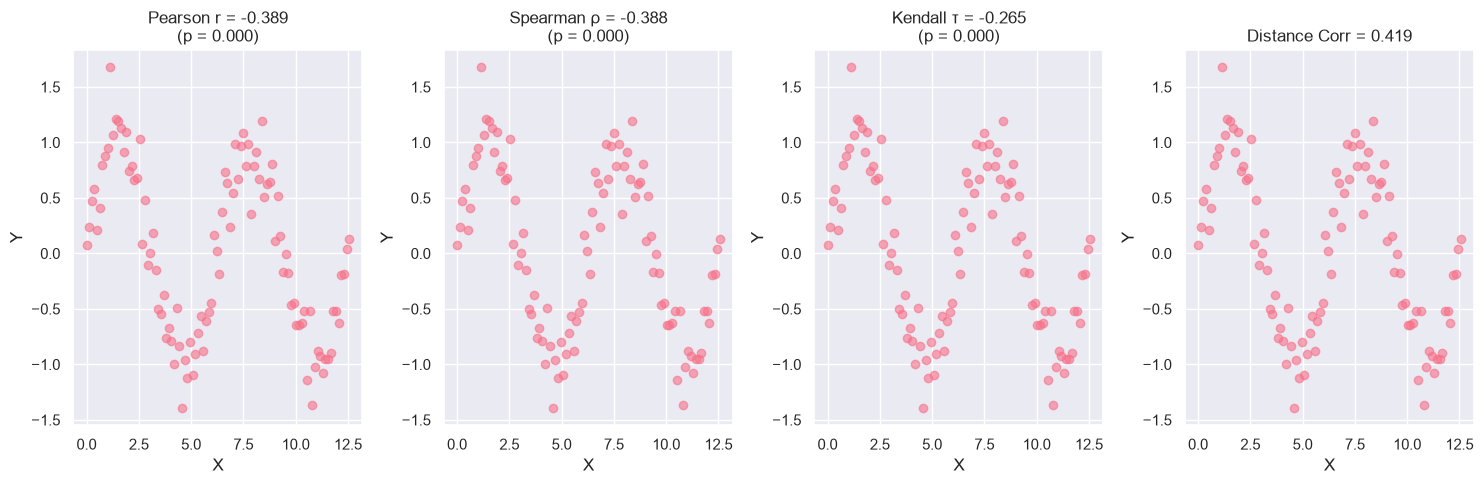

Correlation comparison for Sinusoidal relationship:
pearson: -0.389 (p=0.000)
spearman: -0.388 (p=0.000)
kendall: -0.265 (p=0.000)
distance: 0.419


In [23]:
# Example 3: Sinusoidal relationship
x = np.linspace(0, 4*np.pi, 100)
y = np.sin(x) + np.random.normal(0, 0.2, 100)

# Compare correlations
correlations = compare_correlation_methods(x, y)
print("Correlation comparison for Sinusoidal relationship:")

for method, (corr, p) in correlations.items():
    if method == "distance":
        print(f"{method}: {corr:.3f}")
    else:
        print(f"{method}: {corr:.3f} (p={p:.3f})")

### Exercise 8: Explaining Linear Regression Coefficients


Suppose your model is:

$$
\widehat{Price} = 50 + 1.2 \times Size
$$

where price is in thousands of dollars and size is in m².

Instead of saying:

> “Adding 1 m² **causes** the apartment price to increase by $1,200.”

we actually say:

> **“Apartments that are 1 m² larger are associated with about $1,200 higher predicted price, holding the other model features constant.”**

#### So what can you actually use the coefficient for?

* **Prediction:** A 10 m² larger apartment contributes about `10 × 1.2 = $12,000` more to the model's predicted price.
* **Understanding relationships:** It tells you the direction and size of the relationship the model found: larger apartments tend to have higher prices.
* **Comparing otherwise similar observations:** If two apartments differ mainly in size by 20 m², the model predicts about a `$24,000` difference attributable to the size term.
* **Explaining the model:** You can explain how each feature contributes to its predictions.

The distinction is:

> **Prediction question:** “What price would I expect for apartments with different sizes?” → regression coefficient is useful.

> **Causal question:** “If I physically add 10 m² to this apartment, will its value increase by exactly $12,000?” → ordinary regression alone cannot tell you that.


# 5. Conclusions and Key Takeaways

Let's summarize what we've learned about EDA for machine learning:

### Key Takeaways

1. **Why explore data before modeling?**
   - Identify data quality issues (missing values, outliers, duplicates)
   - Understand variable distributions and relationships
   - Inform feature engineering and model selection decisions
   - Prevent costly mistakes and wasted modeling efforts

2. **How distributions affect modeling:**
   - Linear models assume normally distributed residuals
   - Skewed distributions may require transformations
   - Tree-based models are more robust to distribution shapes
   - Outliers affect different algorithms differently

3. **Correlation's role and limitations:**
   - Measures linear relationships between variables
   - Useful for feature selection and understanding relationships
   - Doesn't capture non-linear relationships
   - Sensitive to outliers

4. **Correlation vs. Causation:**
   - Correlation doesn't imply causation
   - Confounding variables can create spurious correlations
   - Causal inference requires additional methods/experiments
   - Important for decision-making vs. pure prediction

# 6. Practice Exercises

Try these exercises to reinforce your learning:

### Exercise A: Your Own Data

1. Load a data set of your choice
2. Perform comprehensive EDA
3. Identify the key insights that would inform your modeling approach
4. Document your findings

In [24]:
# Example solution with the Iris data set
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Final Reflection

Write a brief paragraph (3-5 sentences) explaining how the concepts in this notebook will change your approach to machine learning projects:

**Reflection:**

Understanding the principles of EDA for modeling has fundamentally changed my approach to machine learning projects. Rather than rushing to apply algorithms, I now recognize the critical importance of thoroughly exploring data distributions, relationships, and quality issues first. The distinction between correlation and causation has made me more cautious about interpreting model results and making recommendations, especially for interventions. I've learned that the choice of preprocessing techniques (like scaling and transformation) should be informed by both the data characteristics and the algorithm requirements. Most importantly, I now see EDA not as a preliminary step but as an integral part of the modeling process that directly impacts model performance and interpretability.